# 233 — Condition-CONCATENATED clustering

Every other clustering notebook (210 raw · 212 rawds · 231 minus101 · 232 hg) treats
**one sample = one electrode × condition**, so the dominant structure available to find is
the *condition / modality* axis. This notebook builds the complementary view:

> **one sample = one ELECTRODE**, features = `[audio | picture | reading]` stitched in time

which asks **"what functional *type* is this contact across the whole task?"** rather than
*"which condition is this response?"*.

This is the **same sample construction** the stage-03 **parcellation** decoding and the
stage-04 **pooling** already use — so clusters from this track are directly comparable to
those results.

### Sample filter (mirrors 03's parcellation task)
An electrode is kept iff it

1. has **all three conditions** present, and
2. is **high-activity in ≥ 1** of them.

The gate is applied at the **electrode** level (not per sample), so a contact that only
responds in one condition still contributes its full three-condition profile.

### Feature sets
| feature_set | grid | dims | note |
|---|---|---|---|
| `concat_hg` | 1 × 900 | 900 | HG line (70–150 Hz) per condition, stitched — comparable to 232 |
| `concat_rawds` | 15 × 90 | 1350 | **the exact grid stage-04 pooling matches roles on** |
| `concat_raw` | 129 × 900 | 116 100 | full-resolution baseline (expect curse-of-dimensionality) |

Each is fed to the same `lf_cluster_run.fit_and_save` orchestrator, so outputs land in
`outputs/clustering/{method}/{feature_set}/runs/<id>/` and are picked up automatically by
`index.json`, **MOBA**, 211 validation and 252 recon.

> ⚠️ **213 ranking:** the *condition-selectivity* axis is meaningless here (every sample
> spans all three conditions) and degrades to `n_conditions=0`. Drop or replace that axis
> when ranking a `concat_*` run.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from functions import lf_blob_clustering_config as cfg
from functions import lf_concat as CC
from functions import lf_cluster_run as R

SCRIPT_NAME = '233_concat_clustering.ipynb'


In [2]:
# ── data input ───────────────────────────────
INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

# ── sample filter ────────────────────────────
CONDITIONS            = ('audio', 'picture', 'reading')
REQUIRE_HIGH_ACTIVITY = True     # keep electrode iff high-activity in >=1 condition

# ── representation ───────────────────────────
HG_BAND = (70.0, 150.0)
FMAX    = 500.0

# ── clustering ───────────────────────────────
# Wider floor than 232 ([6..20]): this is a new representation, so don't assume where
# the silhouette optimum sits. Read the silhouette-vs-K curve before trusting best_k.
K_RANGE      = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
HC_METHOD    = 'ward'
HC_METRIC    = 'euclidean'
RANDOM_STATE = cfg.RANDOM_STATE

# concat_raw is 116k features — set False to skip it on a quick pass.
RUN_CONCAT_RAW = True

print('conditions   :', CONDITIONS, '| gate high-activity>=1:', REQUIRE_HIGH_ACTIVITY)
print('K_RANGE      :', K_RANGE)


conditions   : ('audio', 'picture', 'reading') | gate high-activity>=1: True
K_RANGE      : [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## 1 — Build the concatenated dataset

`build_concat_dataset` loads the **ungated** canonical ERSPs (cached separately in
`outputs/_dataset/concat_source/`), groups them by electrode, and applies the two-part
filter above. `X_concat` is `(n_electrodes, 129, 3×300)`.


In [3]:
df_contacts, X_concat = CC.build_concat_dataset(
    INPUT_DIR, conditions=CONDITIONS, require_high_activity=REQUIRE_HIGH_ACTIVITY)

print(f'\nconcat dataset: {len(df_contacts)} electrodes · X_concat={X_concat.shape}')
print('patients:', df_contacts['patient_id'].nunique())
df_contacts.head()


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\_dataset\concat_source
  8460 samples · X_3d.shape=(8460, 129, 300)
[lf_concat] dropped 184 subdural GRID contacts {'PAT_3415': 184} — their depth contacts are kept
[lf_concat] excluded patients ['EL044'] — 108 rows removed
[lf_concat] 1060 electrodes (audio+picture+reading) · X_concat=(1060, 129, 900)
[lf_concat]   dropped 149 (missing a condition), 1613 (no high-activity condition)
[lf_concat]   high-activity in 1/2/3 conditions: 604 / 241 / 215

concat dataset: 1060 electrodes · X_concat=(1060, 129, 900)
patients: 24


,sample_idx,patient_id,contact_norm,electrode,task,condition,n_high_activity,file_path,file_path_audio,file_path_picture,file_path_reading
0,0,EL030,AHL1,aH_L1,LM,concat,3,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
1,1,EL030,AHL10,aH_L10,LM,concat,3,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
2,2,EL030,AHL11,aH_L11,LM,concat,3,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
3,3,EL030,AHL12,aH_L12,LM,concat,3,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...
4,4,EL030,AHL2,aH_L2,LM,concat,3,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...,\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\...


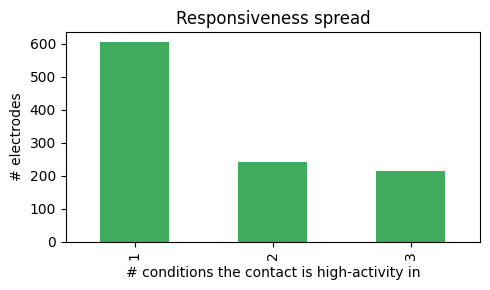

In [4]:
# How many conditions is each contact actually responsive in? (1 = modality-specific,
# 3 = responds across the board). Useful context for interpreting the clusters.
ax = df_contacts['n_high_activity'].value_counts().sort_index().plot.bar(
    figsize=(5, 3), color='#41ab5d')
ax.set_xlabel('# conditions the contact is high-activity in')
ax.set_ylabel('# electrodes'); ax.set_title('Responsiveness spread')
plt.tight_layout(); plt.show()


## 2 — Feature matrices

Three representations of the same concatenated map. `concat_rawds` downsamples **per
condition block** (never across the seam) with the same routine stage-04 pooling uses,
so its grid is identical to the pooling DS grid.


In [5]:
X_hg    = CC.concat_hg_features(X_concat, hg_band=HG_BAND, fmax=FMAX)
X_rawds = CC.concat_rawds_features(X_concat, n_blocks=len(CONDITIONS), fmax_hz=FMAX)
print('concat_hg   :', X_hg.shape)
print('concat_rawds:', X_rawds.shape)

if RUN_CONCAT_RAW:
    X_raw = CC.concat_raw_features(X_concat)
    print('concat_raw  :', X_raw.shape, f'({X_raw.nbytes/1e6:.0f} MB)')


[build_hg_feature_matrix] X_hg.shape=(1060, 900)  hg_band=(70.0, 150.0) Hz  fmax=500.0 Hz
concat_hg   : (1060, 900)
concat_rawds: (1060, 1350)
concat_raw  : (1060, 116100) (492 MB)


## 3 — Cluster

Each feature set × {K-Means, Ward}. `fit_and_save` writes the run dir, registers it in
`index.json`, and renders the standard figure set (silhouette knife + PCA, silhouette-vs-K,
centroids, similarity/centroid-distance heatmaps).


In [6]:
# ── concat_hg ────────────────────────────────
m = R.fit_and_save(
    X_hg, df_keep=df_contacts, method='kmeans', feature_set='concat_hg',
    params={'k_range': K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    method_label='K-Means', feature_set_label='Concatenated HG [a|p|r]',
    feature_names=CC.concat_feature_names('concat_hg'), notebook=SCRIPT_NAME)
print('best K (kmeans/concat_hg):', m['summary']['best_k'])

m = R.fit_and_save(
    X_hg, df_keep=df_contacts, method='hierarchical', feature_set='concat_hg',
    params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'k_range': K_RANGE},
    method_label='Hierarchical', feature_set_label='Concatenated HG [a|p|r]',
    feature_names=CC.concat_feature_names('concat_hg'), notebook=SCRIPT_NAME)
print('best K (hc/concat_hg):', m['summary']['best_k'])


  K=  4  sil=0.1636
  K=  5  sil=0.1633
  K=  6  sil=0.1574
  K=  7  sil=0.1034
  K=  8  sil=0.1267
  K=  9  sil=0.1180
  K= 10  sil=0.1270
  K= 11  sil=0.1165
  K= 12  sil=0.1102
  K= 13  sil=0.1127
  K= 14  sil=0.1141
  K= 15  sil=0.1182
  K= 16  sil=0.1263
  K= 17  sil=0.1261
  K= 18  sil=0.1228
  K= 19  sil=0.1297
  K= 20  sil=0.1318

[KMeans] Best K=4  silhouette=0.1636
[fit_and_save] sweep statistics for K=[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] -> sweep_metrics.csv
[fit_and_save] kmeans/concat_hg/20260802_220720
  n_samples=1060 n_clusters=4 silhouette=0.164
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\kmeans\concat_hg\runs\20260802_220720
best K (kmeans/concat_hg): 4
[HC] method=ward  metric=euclidean  n=1060  cophenetic_r=0.391
  HC sweep k=4: silhouette=0.150
  HC sweep k=5: silhouette=0.153
  HC sweep k=6: silhouette=0.161
  HC sweep k=7: silhouette=0.163
  HC sweep k=8: silhouette=0.098

In [7]:
# ── concat_rawds (same grid as stage-04 pooling) ──
m = R.fit_and_save(
    X_rawds, df_keep=df_contacts, method='kmeans', feature_set='concat_rawds',
    params={'k_range': K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
    method_label='K-Means', feature_set_label='Concatenated 15-band [a|p|r]',
    feature_names=CC.concat_feature_names('concat_rawds'), notebook=SCRIPT_NAME)
print('best K (kmeans/concat_rawds):', m['summary']['best_k'])

m = R.fit_and_save(
    X_rawds, df_keep=df_contacts, method='hierarchical', feature_set='concat_rawds',
    params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'k_range': K_RANGE},
    method_label='Hierarchical', feature_set_label='Concatenated 15-band [a|p|r]',
    feature_names=CC.concat_feature_names('concat_rawds'), notebook=SCRIPT_NAME)
print('best K (hc/concat_rawds):', m['summary']['best_k'])


  K=  4  sil=0.0939
  K=  5  sil=0.0976
  K=  6  sil=0.1044
  K=  7  sil=0.0825
  K=  8  sil=0.0814
  K=  9  sil=0.0853
  K= 10  sil=0.0881
  K= 11  sil=0.0887
  K= 12  sil=0.0836
  K= 13  sil=0.0932
  K= 14  sil=0.0918
  K= 15  sil=0.1018
  K= 16  sil=0.1042
  K= 17  sil=0.1038
  K= 18  sil=0.1013
  K= 19  sil=0.1066
  K= 20  sil=0.1075

[KMeans] Best K=20  silhouette=0.1075
[fit_and_save] sweep statistics for K=[4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] -> sweep_metrics.csv
[fit_and_save] kmeans/concat_rawds/20260802_220808
  n_samples=1060 n_clusters=20 silhouette=0.108
  -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\clustering\kmeans\concat_rawds\runs\20260802_220808
best K (kmeans/concat_rawds): 20
[HC] method=ward  metric=euclidean  n=1060  cophenetic_r=0.315
  HC sweep k=4: silhouette=0.051
  HC sweep k=5: silhouette=0.052
  HC sweep k=6: silhouette=0.060
  HC sweep k=7: silhouette=0.068
  HC sweep k=8: silh

In [9]:
# # ── concat_raw (full resolution baseline) ─────
# if RUN_CONCAT_RAW:
#     m = R.fit_and_save(
#         X_raw, df_keep=df_contacts, method='kmeans', feature_set='concat_raw',
#         params={'k_range': K_RANGE, 'random_state': RANDOM_STATE, 'n_init': 20},
#         method_label='K-Means', feature_set_label='Concatenated full-res [a|p|r]',
#         notebook=SCRIPT_NAME)
#     print('best K (kmeans/concat_raw):', m['summary']['best_k'])

#     m = R.fit_and_save(
#         X_raw, df_keep=df_contacts, method='hierarchical', feature_set='concat_raw',
#         params={'linkage': HC_METHOD, 'metric': HC_METRIC, 'k_range': K_RANGE},
#         method_label='Hierarchical', feature_set_label='Concatenated full-res [a|p|r]',
#         notebook=SCRIPT_NAME)
#     print('best K (hc/concat_raw):', m['summary']['best_k'])
# else:
#     print('[skip] RUN_CONCAT_RAW = False')


In [10]:
# ── per-cluster centroid chips ("cluster averages") ──
# fit_and_save does NOT write these — each clustering notebook calls it explicitly.
# concat_hg renders as line + SEM; the 2-D sets as heatmaps. Both get the condition
# seams drawn so the [audio | picture | reading] structure is readable on the chip.
from functions import lf_centroids as LC

_FEATS = {'concat_hg': (X_hg, None), 'concat_rawds': (X_rawds, (15, 90))}
if RUN_CONCAT_RAW:
    _FEATS['concat_raw'] = (X_raw, (129, 900))

import glob
for _fs, (_X, _shape) in _FEATS.items():
    for _method in ('kmeans', 'hierarchical'):
        for _rd in sorted(glob.glob(f'outputs/clustering/{_method}/{_fs}/runs/*/')):
            res = LC.save_per_cluster_centroids(Path(_rd), _X, _fs, _method,
                                                centroid_shape=_shape, verbose=False)
            print(f'  {_method}/{_fs} {Path(_rd).name}: {sum(res.values())} chips')


  kmeans/concat_hg 20260728_110801: 0 chips
  kmeans/concat_hg 20260731_174851: 0 chips
  kmeans/concat_hg 20260731_215405: 0 chips
  kmeans/concat_hg 20260802_220720: 208 chips
  hierarchical/concat_hg 20260728_110823: 0 chips
  hierarchical/concat_hg 20260731_215434: 0 chips
  hierarchical/concat_hg 20260802_220747: 211 chips
  kmeans/concat_rawds 20260728_110829: 0 chips
  kmeans/concat_rawds 20260731_215439: 0 chips
  kmeans/concat_rawds 20260802_220808: 224 chips
  hierarchical/concat_rawds 20260728_110904: 0 chips
  hierarchical/concat_rawds 20260731_215519: 0 chips
  hierarchical/concat_rawds 20260802_220847: 224 chips
  kmeans/concat_raw 20260728_110909: 0 chips
  kmeans/concat_raw 20260731_215525: 0 chips
  kmeans/concat_raw 20260802_220854: 0 chips
  hierarchical/concat_raw 20260728_114228: 0 chips
  hierarchical/concat_raw 20260731_224035: 0 chips


## 4 — Next

- **211** — consensus stability / gap / anatomy on these runs (all X-agnostic, works as-is).
- **213** — ranking: **drop the condition-selectivity axis** for `concat_*` (it is
  degenerate here) or replace it with a cross-condition consistency score.
- **252** — recon. Cleaner for this track: one row per electrode, so no duplicate contacts.
- **MOBA** — the runs appear in the dropdown automatically once `index.json` + `labels.csv`
  are committed. `condition` is set to `'concat'` so the condition view renders one category.
- **Compare** against the stage-04 pooling roles: `concat_rawds` uses the identical grid,
  so a cluster ↔ role cross-tab is apples-to-apples.
